## Loading data

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import shap
from sklearn.inspection import permutation_importance
from haversine import haversine
from sklearn.inspection import PartialDependenceDisplay

In [8]:
data = pd.read_csv('all_airbnbs.csv', sep=';',low_memory=False)

Removing variables that are related to Occupancy Rate or id information to avoid noise and data leakage.

In [9]:
data = data.drop(columns=['estimated_occupancy_l365d', 'estimated_revenue_l365d', 'availability_30', 'availability_60', 'availability_90', 'availability_365',
                          'has_availability', 'availability_eoy','id', 'name', 'host_id', 'host_name', 'host_location', 'host_about', 'description', 'first_review', 'last_review'])

## Missing data

In [10]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)
missing_data[:15]

,missing value,percentage
review_scores_location,15056,21.522100
review_scores_value,15056,21.522100
review_scores_checkin,15056,21.522100
review_scores_cleanliness,15056,21.522100
review_scores_communication,15055,21.520670
review_scores_accuracy,15055,21.520670
reviews_per_month,15053,21.517811
review_scores_rating,15053,21.517811
host_neighbourhood,8243,11.783121
avg_price_by_numberroms,7456,10.658128


In [11]:
data = data.drop(columns=['host_neighbourhood'])
data = data.drop(columns=['bathrooms_text'])
data = data.drop(columns=['host_verifications'])

In [12]:
data['review_scores_accuracy'] = data['review_scores_accuracy'].fillna(-1)
data['review_scores_checkin'] = data['review_scores_checkin'].fillna(-1)
data['review_scores_location'] = data['review_scores_location'].fillna(-1)
data['review_scores_cleanliness'] = data['review_scores_cleanliness'].fillna(-1)
data['review_scores_value'] = data['review_scores_value'].fillna(-1)
data['review_scores_communication'] = data['review_scores_communication'].fillna(-1)
data['review_scores_rating'] = data['review_scores_rating'].fillna(-1)
data['reviews_per_month'] = data['reviews_per_month'].fillna(-1)

-1 means no ratings, models consider it as a separate category

In [13]:
nonnumeric = data.select_dtypes(include='object')
nonnumeric.head()

,host_since,host_response_time,neighbourhood_cleansed,property_type,room_type,city
0,2017-11-11 00:00:00.000,within a few hours,Merton,Private room in home,Private room,london
1,2025-08-03 00:00:00.000,within a day,Barnet,Private room in home,Private room,london
2,2019-01-28 00:00:00.000,NaN,Barking and Dagenham,Private room in home,Private room,london
3,2023-10-09 00:00:00.000,a few days or more,Harrow,Private room in rental unit,Private room,london
4,2023-10-09 00:00:00.000,NaN,Camden,Private room in home,Private room,london


In [14]:
data['host_since'] = pd.to_datetime(data['host_since'], errors='coerce', dayfirst=True)
data['host_since'] = data['host_since'].dt.year
mode_year = data['host_since'].mode()[0]
data['host_since'] = data['host_since'].fillna(mode_year)
data['host_since'] = data['host_since'].astype(int)

In [15]:
data['host_since'].value_counts()

host_since
2015    46795
2016     2532
2023     2438
2014     2250
2024     2188
2019     1959
2022     1892
2017     1872
2018     1838
2025     1332
2013     1262
2021     1088
2012     1029
2020      968
2011      446
2010       60
2009        7
Name: count, dtype: int64

In [16]:
data['host_response_time'].unique()

array(['within a few hours', 'within a day', nan, 'a few days or more',
       'within an hour'], dtype=object)

In [17]:
data['room_type'].unique()

array(['Private room', 'Shared room', 'Entire home/apt', 'Hotel room'],
      dtype=object)

In [18]:
meal_map = {'a few days or more': 1, 'within a day': 2, 'within a few hours': 3, 'within an hour': 4}
data['host_response_time'] = data['host_response_time'].map(meal_map)
data['host_response_time'] = data['host_response_time'].fillna(0).astype(int)
room_map = {'Shared room': 0,'Hotel room': 1, 'Private room': 2, 'Entire home/apt': 3}
data['room_type'] = data['room_type'].map(room_map)

In [19]:
cols_to_encode = ['property_type', 'neighbourhood_cleansed', 'city']
data = pd.get_dummies(data, columns=cols_to_encode)

In [20]:
data.head()

,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,...,neighbourhood_cleansed_Westbury-on-Trym & Henleaze,neighbourhood_cleansed_Westminster,neighbourhood_cleansed_Whalley Range,neighbourhood_cleansed_Wigan District,neighbourhood_cleansed_Windmill Hill,neighbourhood_cleansed_Withington,neighbourhood_cleansed_Woodhouse Park,city_bristol,city_london,city_manchester
0,2017,3,0.71,0.33,0,1.0,2.0,1,1,51.412309,...,False,False,False,False,False,False,False,False,True,False
1,2025,2,0.50,0.00,0,1.0,1.0,1,0,51.597830,...,False,False,False,False,False,False,False,False,True,False
2,2015,0,0.00,0.00,0,1.0,5.0,0,1,51.557640,...,False,False,False,False,False,False,False,False,True,False
3,2023,1,0.33,0.00,0,1.0,1.0,1,0,51.605240,...,False,False,False,False,False,False,False,False,True,False
4,2023,0,0.00,0.00,0,1.0,1.0,1,0,51.559361,...,False,False,False,False,False,False,False,False,True,False


In [21]:
data = data[~data['amenities_precentage'].isna()]

In [22]:
data['avg_price_by_numberroms'] = data['avg_price_by_numberroms'].fillna(data['avg_price_by_numberroms'].mean())
data['avg_price_per_sq_m_by_neighbourhood'] = data['avg_price_per_sq_m_by_neighbourhood'].fillna(data['avg_price_per_sq_m_by_neighbourhood'].mean())
data = data[~data['Occupancy_Rate'].isna()]

In [23]:
data = data[~data['host_total_listings_count'].isna()]

In [24]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)
missing_data[:5]

,missing value,percentage
host_since,0,0.0
host_response_time,0,0.0
host_response_rate,0,0.0
host_acceptance_rate,0,0.0
host_is_superhost,0,0.0


In [25]:
data = data.drop(columns=['host_total_listings_count','calculated_host_listings_count_entire_homes','calculated_host_listings_count_private_rooms',
                          'calculated_host_listings_count_shared_rooms','calculated_host_listings_count'])

In [26]:
data = data.drop(columns=['number_of_reviews_ltm','number_of_reviews_l30d','number_of_reviews_l30d','number_of_reviews_ly'])

## Outliers

In [27]:
data.describe().T.apply(lambda s: s.apply('{0:.5f}'.format))

,count,mean,std,min,25%,50%,75%,max
host_since,65026.00000,2016.33316,3.01148,2009.00000,2015.00000,2015.00000,2016.00000,2025.00000
host_response_time,65026.00000,3.09444,1.34872,0.00000,2.00000,4.00000,4.00000,4.00000
host_response_rate,65026.00000,0.81411,0.34865,0.00000,0.87000,1.00000,1.00000,1.00000
host_acceptance_rate,65026.00000,0.74982,0.35130,0.00000,0.60000,0.95000,1.00000,1.00000
host_is_superhost,65026.00000,0.24176,0.42816,0.00000,0.00000,0.00000,0.00000,1.00000
host_listings_count,65026.00000,65.96749,469.34974,1.00000,1.00000,3.00000,17.00000,5469.00000
host_has_profile_pic,65026.00000,0.94794,0.22214,0.00000,1.00000,1.00000,1.00000,1.00000
host_identity_verified,65026.00000,0.91648,0.27667,0.00000,1.00000,1.00000,1.00000,1.00000
latitude,65026.00000,51.54414,0.26965,51.29594,51.48302,51.51283,51.53797,53.65098
longitude,65026.00000,-0.25236,0.53109,-2.70881,-0.19959,-0.13926,-0.07432,0.27896


In [28]:
q1 = np.quantile(data['price'], 0.25)
q3 = np.quantile(data['price'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['price'] > 3 * upper_lim) | (data['price'] < 3 * lower_lim)]
outliers['price'].shape

(410,)

In [29]:
data = data[~((data['price'] > 3 * upper_lim) | (data['price'] < 3 * lower_lim))]

In [30]:
q1 = np.quantile(data['reviews_per_month'], 0.25)
q3 = np.quantile(data['reviews_per_month'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['reviews_per_month'] > 5 * upper_lim) | (data['reviews_per_month'] < 5 * lower_lim)]
outliers['reviews_per_month'].shape

(7,)

In [31]:
data = data[~((data['reviews_per_month'] > 5 * upper_lim) | (data['reviews_per_month'] < 5 * lower_lim))]

In [32]:
q1 = np.quantile(data['host_listings_count'], 0.25)
q3 = np.quantile(data['host_listings_count'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['host_listings_count'] > 3 * upper_lim) | (data['host_listings_count'] < 3 * lower_lim)]
outliers['host_listings_count'].shape

(3108,)

In [33]:
data = data[~((data['host_listings_count'] > 3 * upper_lim) | (data['host_listings_count'] < 3 * lower_lim))]

In [34]:
q1 = np.quantile(data['maximum_nights'], 0.25)
q3 = np.quantile(data['maximum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['maximum_nights'] > 1.5 * upper_lim) | (data['maximum_nights'] < 1.5 * lower_lim)]
outliers['maximum_nights'].shape

(1,)

In [35]:
data = data[~((data['maximum_nights'] > 1.5 * upper_lim) | (data['maximum_nights'] < 1.5 * lower_lim))]

In [36]:
q1 = np.quantile(data['minimum_nights'], 0.25)
q3 = np.quantile(data['minimum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(1.5*iqr)
lower_lim = q1-(1.5*iqr)
outliers = data[(data['minimum_nights'] > 5 * upper_lim) | (data['minimum_nights'] < 5 * lower_lim)]
outliers['minimum_nights'].shape

(650,)

In [37]:
data.describe().T.apply(lambda s: s.apply('{0:.5f}'.format))

,count,mean,std,min,25%,50%,75%,max
host_since,61500.00000,2016.31333,3.01804,2009.00000,2015.00000,2015.00000,2016.00000,2025.00000
host_response_time,61500.00000,3.06907,1.36257,0.00000,2.00000,4.00000,4.00000,4.00000
host_response_rate,61500.00000,0.80919,0.35388,0.00000,0.87000,1.00000,1.00000,1.00000
host_acceptance_rate,61500.00000,0.74593,0.35469,0.00000,0.60000,0.95000,1.00000,1.00000
host_is_superhost,61500.00000,0.25143,0.43384,0.00000,0.00000,0.00000,1.00000,1.00000
host_listings_count,61500.00000,12.50486,21.42340,1.00000,1.00000,3.00000,13.00000,123.00000
host_has_profile_pic,61500.00000,0.94688,0.22428,0.00000,1.00000,1.00000,1.00000,1.00000
host_identity_verified,61500.00000,0.92148,0.26899,0.00000,1.00000,1.00000,1.00000,1.00000
latitude,61500.00000,51.54594,0.27586,51.29594,51.48235,51.51301,51.53896,53.65098
longitude,61500.00000,-0.25127,0.53017,-2.70881,-0.20029,-0.13816,-0.07277,0.27896


In [38]:
bins = [0, 14, 30, 90, 364, 366, 800]
labels = ['1-14 dni', '15-30 dni', '31-90 dni', '91-364 dni', 'Dokładnie 365', 'Powyżej 365']

df_diag = data.copy()
df_diag['max_nights_group'] = pd.cut(df_diag['maximum_nights'], bins=bins, labels=labels)

# Grupujemy i sprawdzamy obłożenie
diag_1 = df_diag.groupby('max_nights_group',observed=False)['Occupancy_Rate'].agg(['mean', 'count'])
print("AVERAGE OCCUPANCY DEPENDING ON MAXIMUM NIGHTS SETTING:")
print(diag_1)

AVERAGE OCCUPANCY DEPENDING ON MAXIMUM NIGHTS SETTING:
                      mean  count
max_nights_group                 
1-14 dni          0.565579   4331
15-30 dni         0.531181   6073
31-90 dni         0.527249   6144
91-364 dni        0.456075   3165
Dokładnie 365     0.360050  29958
Powyżej 365       0.403043   1435


In [39]:
print("Correlation with the number of reviews in the last year:")
# Czy ci z max_nights > 300 mają znacznie mniej recenzji (czyli mniejszy ruch)?
print(df_diag.groupby('max_nights_group', observed=False)['reviews_per_month'].mean())

Correlation with the number of reviews in the last year:
max_nights_group
1-14 dni         1.120085
15-30 dni        1.093290
31-90 dni        0.873123
91-364 dni       0.799438
Dokładnie 365    0.689805
Powyżej 365      0.967066
Name: reviews_per_month, dtype: float64


In [40]:
print("Average number of host listings in a given group:")
print(df_diag.groupby('max_nights_group', observed=False)['host_listings_count'].mean())

Average number of host listings in a given group:
max_nights_group
1-14 dni          6.380974
15-30 dni         6.604479
31-90 dni         7.010254
91-364 dni       15.647709
Dokładnie 365    15.224347
Powyżej 365       7.763763
Name: host_listings_count, dtype: float64


## City centers and universities

The Haversine formula is a mathematical method for calculating the shortest straight-line distance between two points on the surface of a sphere (e.g., Earth), taking into account its curvature. Instead of standard three-dimensional distances, it uses geographic coordinates (latitude and longitude).

In [41]:
city_centers = {
    'london': (51.5074, -0.1278),
    'manchester': (53.4808, -2.2426),
    'bristol': (51.4545, -2.5879)}

universities = {
    'london': [(51.5246, -0.1340),(51.4988, -0.1749),(51.5115, -0.1160),(51.5146, -0.1167)],
    'manchester': [(53.4668, -2.2339),(53.4723, -2.2397)],
    'bristol': [(51.4584, -2.6030),(51.5001, -2.5483)]}

In [42]:
def get_city(row):
    if row['city_london'] == True:
        return 'london'
    elif row['city_manchester'] == True:
        return 'manchester'
    elif row['city_bristol'] == True:
        return 'bristol'
    return None


def distance_to_center(row):
    city = get_city(row)

    if city is None:
        return np.nan

    center = city_centers[city]
    apartment = (row['latitude'],row['longitude'])

    return haversine(apartment,center)

data['distance_to_center_km'] = data.apply(distance_to_center,axis=1)

In [43]:
def distance_to_nearest_university(row):

    city = get_city(row)
    if city is None:
        return np.nan

    apartment = (row['latitude'],row['longitude'])
    distances = []

    for uni in universities[city]:
        dist = haversine(apartment,uni)
        distances.append(dist)
    return min(distances)

data['distance_to_university_km'] = data.apply(distance_to_nearest_university,axis=1)

In [44]:
data

,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,neighbourhood_cleansed_Whalley Range,neighbourhood_cleansed_Wigan District,neighbourhood_cleansed_Windmill Hill,neighbourhood_cleansed_Withington,neighbourhood_cleansed_Woodhouse Park,city_bristol,city_london,city_manchester,distance_to_center_km,distance_to_university_km
0,2017,3,0.71,0.33,0,1.0,1,1,51.412309,-0.170539,...,False,False,False,False,False,False,True,False,10.980471,9.622166
1,2025,2,0.50,0.00,0,1.0,1,0,51.597830,-0.233370,...,False,False,False,False,False,False,True,False,12.425312,10.653233
2,2015,0,0.00,0.00,0,1.0,0,1,51.557640,0.133620,...,False,False,False,False,False,False,True,False,18.925982,17.962825
3,2023,1,0.33,0.00,0,1.0,1,0,51.605240,-0.296100,...,False,False,False,False,False,False,True,False,15.929296,14.350864
4,2023,0,0.00,0.00,0,1.0,1,0,51.559361,-0.142949,...,False,False,False,False,False,False,True,False,5.872057,3.914484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69779,2015,4,1.00,1.00,1,13.0,1,1,53.433858,-2.228425,...,False,False,False,True,False,False,False,True,5.303458,3.680928
69785,2015,4,1.00,1.00,0,1.0,1,1,53.494280,-2.237750,...,False,False,False,False,False,False,False,True,1.532871,2.447471
69787,2015,4,1.00,1.00,0,5.0,1,1,53.463030,-2.179140,...,False,False,False,False,False,False,False,True,4.641687,3.649057
69896,2015,4,1.00,1.00,0,4.0,1,1,53.420560,-2.204080,...,False,False,False,False,False,False,False,True,7.167612,5.507914


## PCA

In [45]:
X = data.drop(columns=['Occupancy_Rate'])
y = data['Occupancy_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
pca = PCA(n_components=3)
X_train_pca_plot=pca.fit_transform(X_train)
X_train_pca_plot

array([[ 0.2035983 , -0.8941903 ,  1.31545674],
       [ 1.9872701 , -0.4424532 ,  1.22384332],
       [-7.10250731, -2.44615523,  1.28932933],
       ...,
       [-5.05209061,  1.70388134, -1.17987168],
       [-0.0707993 , -2.42851376,  2.41257144],
       [ 0.4720924 ,  0.22503194,  0.57094592]], shape=(43050, 3))

Text(0, 0.5, 'pc1')

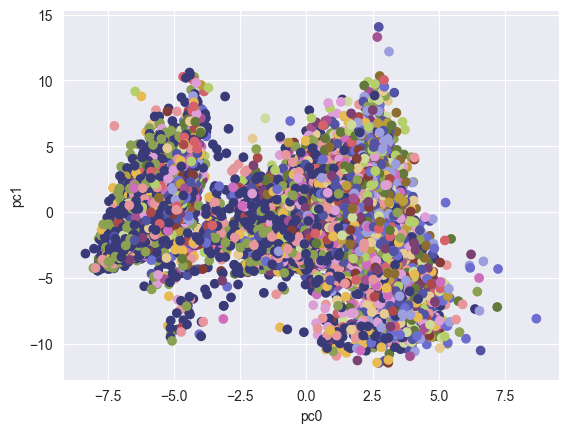

In [47]:
plt.scatter(X_train_pca_plot[:,0],X_train_pca_plot[:,1], c = y_train, cmap ='tab20b')
plt.xlabel('pc0')
plt.ylabel('pc1')

In [48]:
components = np.arange(X_train.shape[1] + 1)
var_ratio = []
for num in components:
  if num == 0:
    var_ratio.append(0.0)
    continue
  pca = PCA(n_components=num)
  pca.fit(X_train)
  var_ratio.append(np.sum(pca.explained_variance_ratio_))

Text(0.5, 1.0, 'Number of components and the coefficient of explained variance')

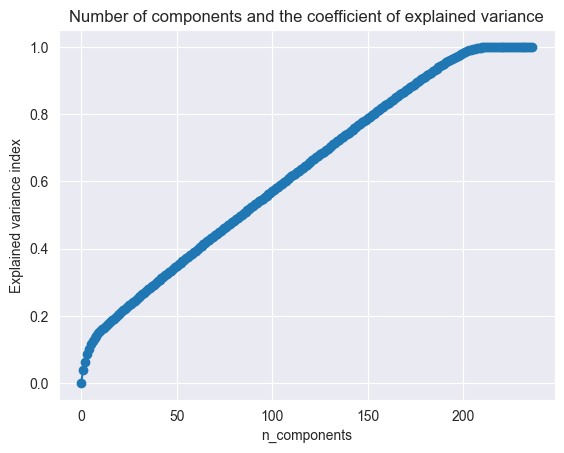

In [49]:
plt.plot(components,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance index')
plt.title('Number of components and the coefficient of explained variance')

## Decision Tree

In [50]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_tree))

R2 Score: -0.43474307562202097


In [51]:
param_grid_tree = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
}

grid_tree = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), param_grid_tree, cv=3, scoring='r2', n_jobs=-1, n_iter=5)
grid_tree.fit(X_train, y_train)

print("Best parameters for a decision tree:", grid_tree.best_params_)

Best parameters for a decision tree: {'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'friedman_mse'}


In [52]:
tree = DecisionTreeRegressor(random_state=42, criterion='friedman_mse', max_depth= 10, max_features= 'log2', min_samples_split=5)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

In [53]:
print("R2 Score:", r2_score(y_test, y_pred_tree))
print("MSE:", mean_squared_error(y_test, y_pred_tree))

R2 Score: 0.09399667373738119
MSE: 0.09974759511370834


In [73]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

                                 Feature  Importance
17                        maximum_nights    0.439654
22                 review_scores_checkin    0.135344
234                distance_to_center_km    0.041972
3                   host_acceptance_rate    0.039215
16                        minimum_nights    0.035496
5                    host_listings_count    0.032396
32   avg_price_per_sq_m_by_neighbourhood    0.029590
2                     host_response_rate    0.024770
1                     host_response_time    0.021621
20                review_scores_accuracy    0.017727


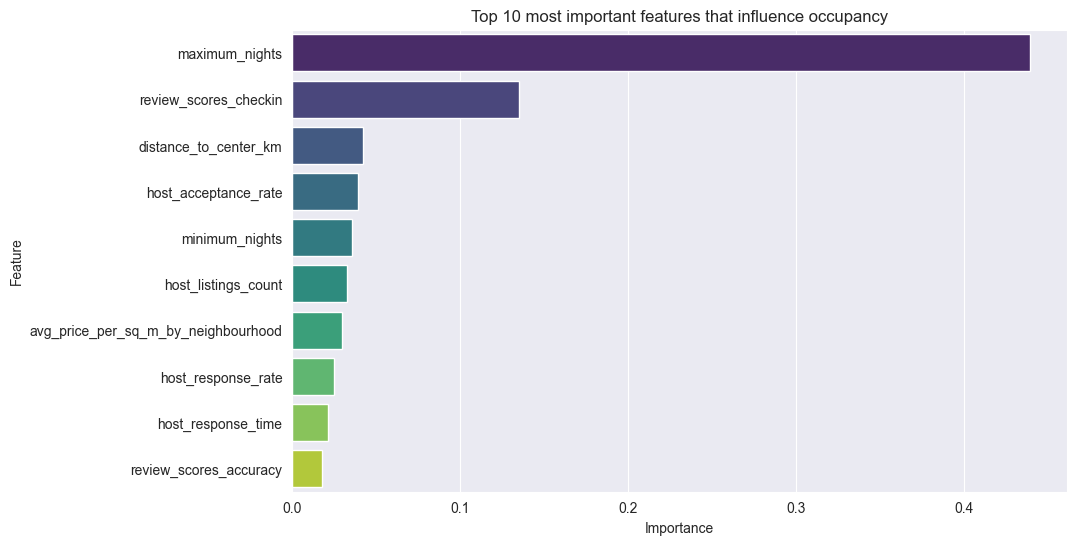

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis', hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 most important features that influence occupancy')
plt.show()

# Regresja

In [4]:
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred=lin_reg.predict(X_test)


mse = mean_squared_error(y_test,y_pred)

r2= r2_score(y_test, y_pred)
print("MSE:", mse)
print("r2:", r2)

NameError: name 'X_train' is not defined

In [ ]:
coefficients = pd.DataFrame({'Feature':X.columns, 'Coefficient': lin_reg.coef_})

coefficients = coefficients.sort_values(by='Coefficient',ascending= False)
coefficients.head(10)

,Feature,Coefficient
25,review_scores_value,0.110394
232,city_london,0.062311
8,latitude,0.058793
20,review_scores_accuracy,0.051967
3,host_acceptance_rate,0.031697
2,host_response_rate,0.020017
19,review_scores_rating,0.019215
22,review_scores_checkin,0.018403
13,bedrooms,0.017437
220,neighbourhood_cleansed_Tower Hamlets,0.015195


# Gradient Boost

In [67]:
gbc=GradientBoostingRegressor(random_state=42)
gbc.fit(X_train, y_train)
y_gbc=gbc.predict(X_test)

In [68]:
print("R2 Score:", r2_score(y_test, y_gbc))
print("MSE:", mean_squared_error(y_test, y_gbc))

R2 Score: 0.17248362717352705
MSE: 0.09110647357903108


In [69]:
param_grid_gbc = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

grid_gbc = RandomizedSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gbc, cv=6, scoring='r2', n_jobs=-1, n_iter=10)
grid_gbc.fit(X_train, y_train)

print("Best parameters for Gradient Boosting Regressor:", grid_gbc.best_params_)

Best parameters for Gradient Boosting Regressor: {'subsample': 0.7, 'n_estimators': 300, 'max_features': None, 'max_depth': 6, 'learning_rate': 0.1}


In [70]:
best_gbc = GradientBoostingRegressor(random_state=42, subsample=1.0, n_estimators=100, learning_rate=0.1, max_depth=4, max_features=None)
best_gbc.fit(X_train, y_train)
y_pred_gbc = best_gbc.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_gbc))
print("MSE:", mean_squared_error(y_test, y_pred_gbc))

R2 Score: 0.1932560302909152
MSE: 0.08881950928692497


In [71]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_gbc.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

                         Feature  Importance
17                maximum_nights    0.272593
5            host_listings_count    0.111180
15                         price    0.062564
235    distance_to_university_km    0.050664
16                minimum_nights    0.049284
3           host_acceptance_rate    0.039881
23   review_scores_communication    0.038377
30          amenities_precentage    0.036250
27             reviews_per_month    0.028515
234        distance_to_center_km    0.025757


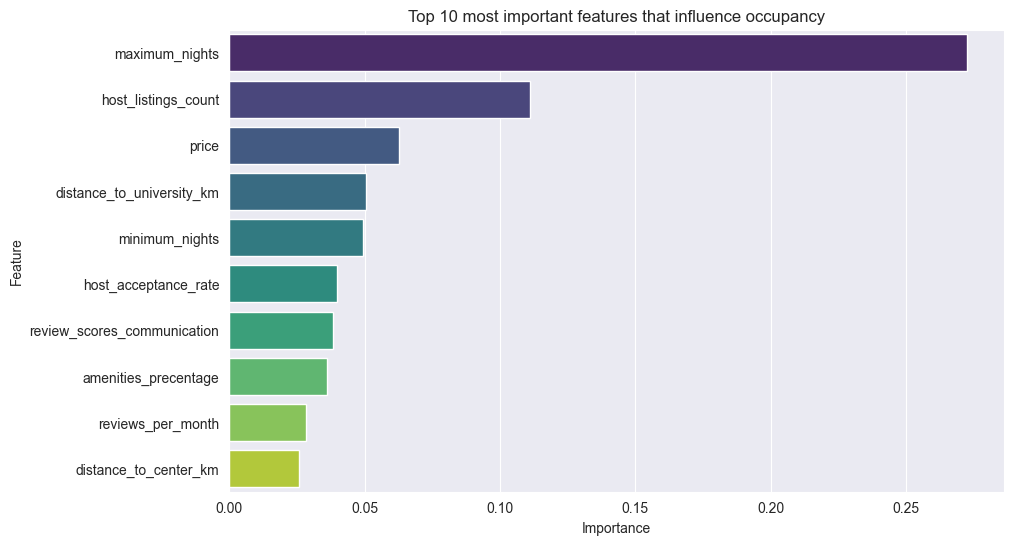

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis', hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 most important features that influence occupancy')
plt.show()

# Las losowy

In [56]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_rf=rf.predict(X_test)

In [57]:
print("R2 Score:", r2_score(y_test, y_rf))
print("MSE:", mean_squared_error(y_test, y_rf))

R2 Score: 0.2788219181362621
MSE: 0.0793990234134894


In [58]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2', n_jobs=-1, n_iter=5)
grid_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_rf.best_params_)

Best parameters for Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [59]:
best_rf = RandomForestRegressor(random_state=42, n_estimators=300, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=30)
best_rf.fit(X_train, y_train)
y_rf = best_rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_rf))
print("MSE:", mean_squared_error(y_test, y_rf))

R2 Score: 0.2822226571315687
MSE: 0.07902461470376584


In [63]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

                       Feature  Importance
17              maximum_nights    0.080150
15                       price    0.064348
8                     latitude    0.058674
9                    longitude    0.055794
30        amenities_precentage    0.054980
235  distance_to_university_km    0.053786
5          host_listings_count    0.051425
234      distance_to_center_km    0.049091
27           reviews_per_month    0.041041
3         host_acceptance_rate    0.037731


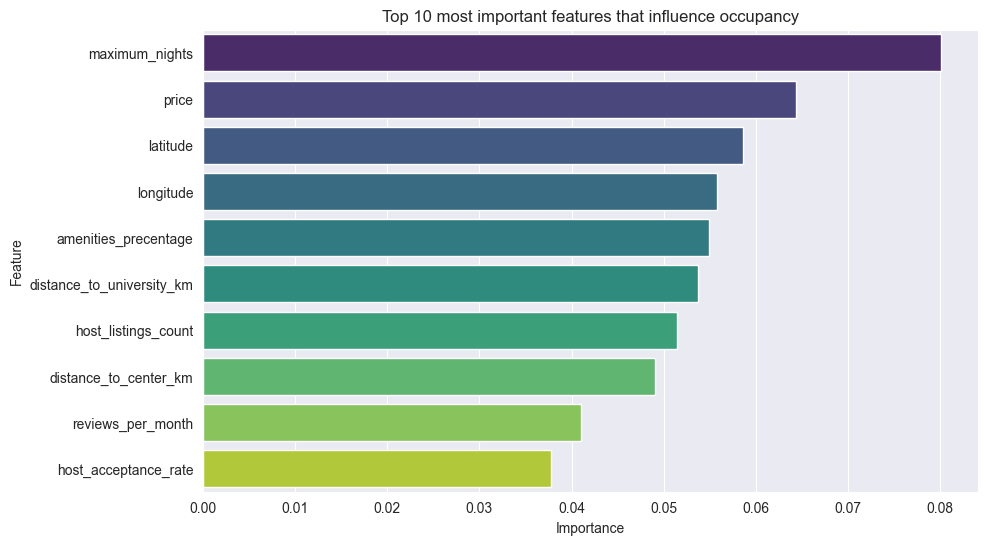

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis', hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 most important features that influence occupancy')
plt.show()

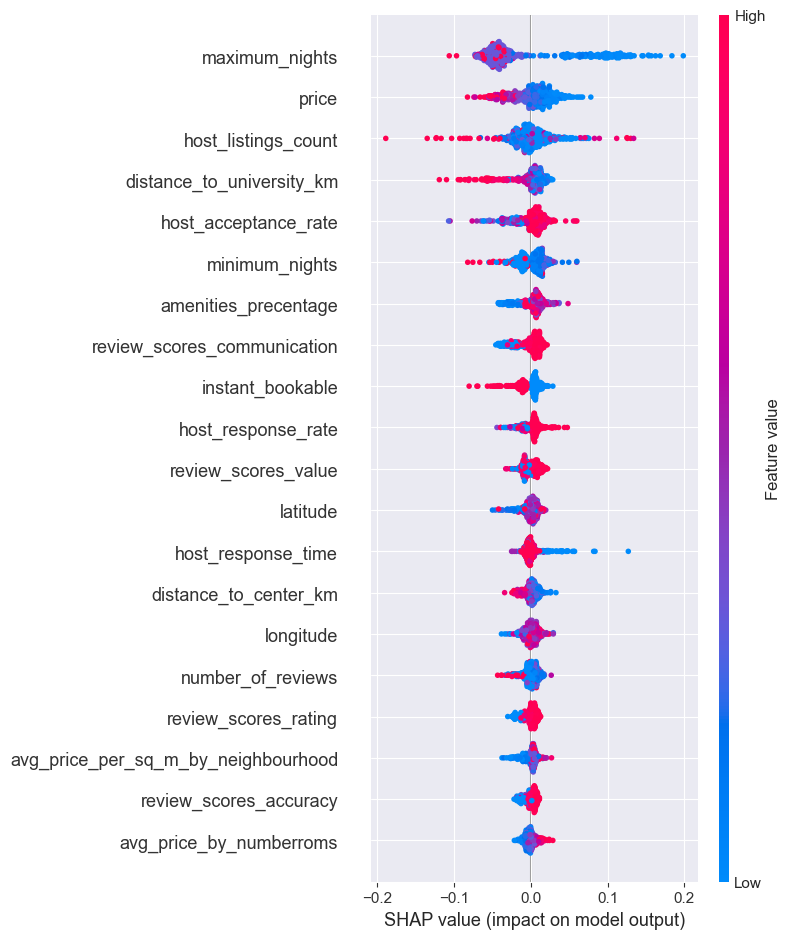

In [66]:
background = shap.sample(X_test, 50)
explainer = shap.TreeExplainer(best_rf)
X_test_sample = shap.sample(X_test, 500)
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

# XgBoost

In [ ]:
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.24798951288958848
MSE: 0.08279355650821173


In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

grid_xgb = RandomizedSearchCV(xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                              param_distributions=param_grid_xgb, cv=3, scoring='r2', n_jobs=-1, n_iter=10, random_state=42)
grid_xgb.fit(X_train, y_train)

print("Best parameters for XGBoost:", grid_xgb.best_params_)

Najlepsze parametry dla XGBoost: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [ ]:
best_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, subsample=0.6, n_estimators=300,
                            max_depth=7, learning_rate=0.05, colsample_bytree=0.9, gamma=0.1)
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))

R2 Score: 0.26446883424604106
MSE: 0.0809792445440461


In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head(10))

                                 Cecha   Ważność
17                      maximum_nights  0.029559
26                    instant_bookable  0.014656
23         review_scores_communication  0.013711
10                           room_type  0.011807
5                  host_listings_count  0.011110
16                      minimum_nights  0.010813
29                           avg_score  0.010583
25                 review_scores_value  0.010214
2                   host_response_rate  0.010115
80  property_type_Private room in home  0.010065


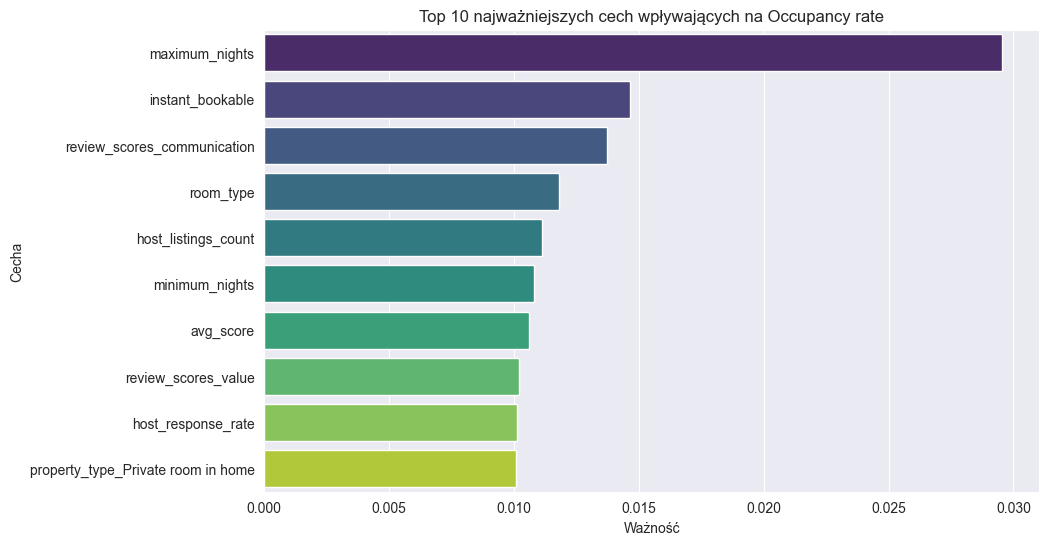

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='viridis', hue='Feature')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 most important features that influence occupancy')
plt.show()

# Sieci neuronowe

In [75]:
mlp_model = MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', alpha=0.05,
                         batch_size=64, early_stopping=True, validation_fraction=0.2, n_iter_no_change=50,
                         max_iter=2000, random_state=42)
mlp_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.05
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [76]:
y_pred_raw = mlp_model.predict(X_test)
y_pred = np.clip(y_pred_raw, 0.0, 1.0)
print(f"MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

MAE: 0.26086904442941816
R2 Score: 0.16118127804390892
MSE: 0.09235082016378979


In [77]:
permutation_results = permutation_importance(
    mlp_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Average': permutation_results.importances_mean,
    'Deviation': permutation_results.importances_std
})
feature_importance = feature_importance.sort_values(by='Importance_Average', ascending=False)
print(feature_importance.head(10))

                       Feature  Importance_Average  Deviation
17              maximum_nights            0.071819   0.003248
15                       price            0.069319   0.002504
1           host_response_time            0.029311   0.001633
5          host_listings_count            0.025901   0.000475
2           host_response_rate            0.019845   0.000741
26            instant_bookable            0.017825   0.001136
25         review_scores_value            0.017488   0.001139
3         host_acceptance_rate            0.014494   0.001145
235  distance_to_university_km            0.012268   0.000930
30        amenities_precentage            0.012246   0.000832


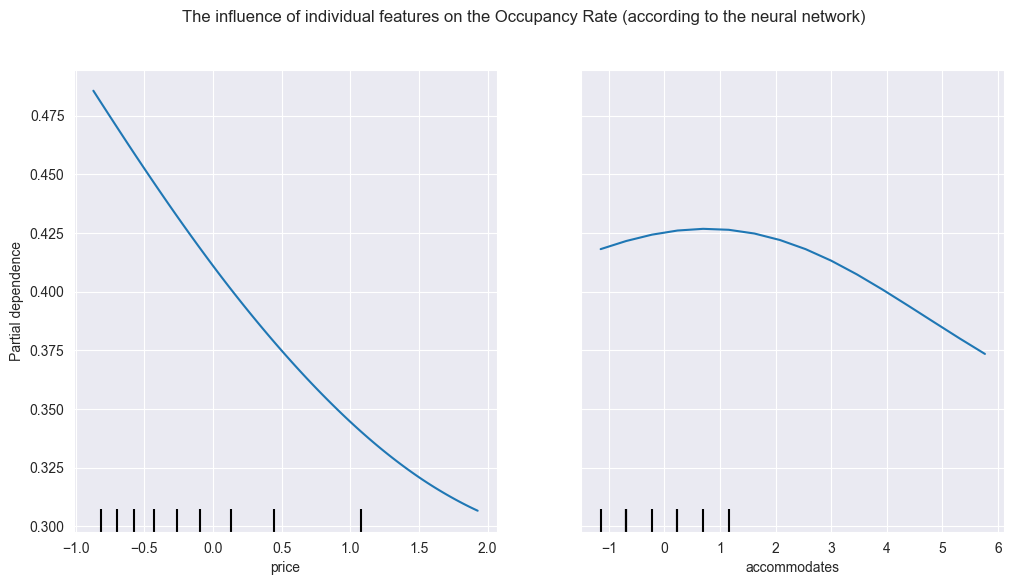

In [80]:
features = ['price', 'accommodates']

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    mlp_model,
    X_test,
    features=features,
    feature_names=X.columns,
    ax=ax
)
plt.suptitle("The influence of individual features on the Occupancy Rate (according to the neural network)")
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

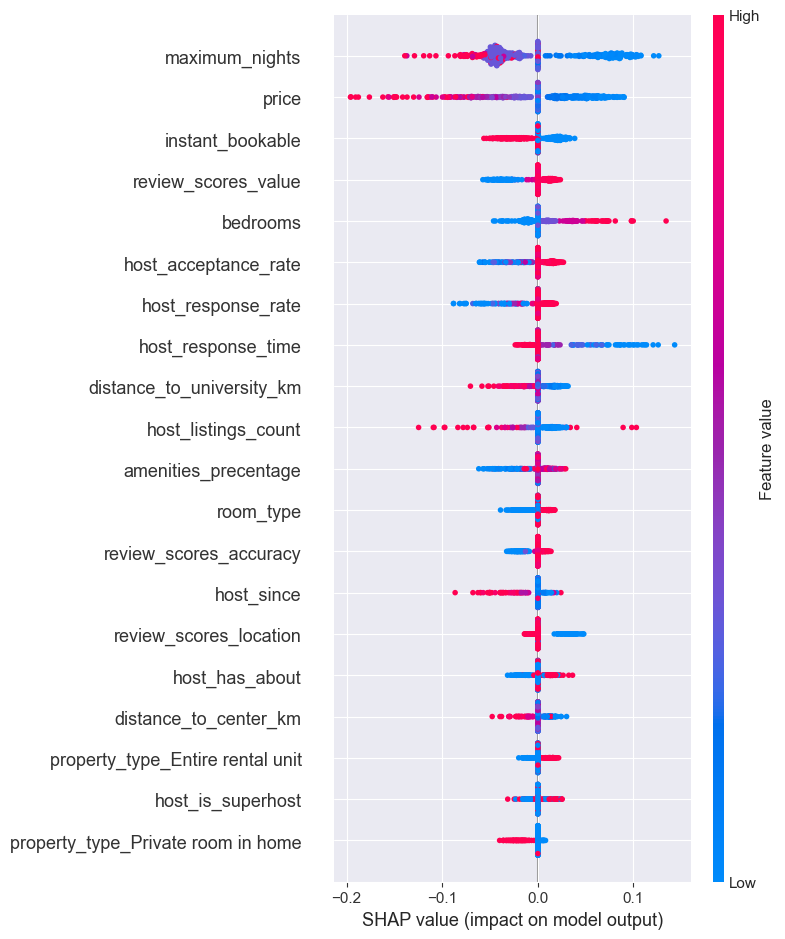

In [81]:
background = shap.sample(X_test, 50)
explainer = shap.KernelExplainer(mlp_model.predict, background)
X_test_sample = shap.sample(X_test, 500)
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

Ten wykres pokazuje nie tylko, jak bardzo dana cecha jest ważna, ale też w jakim kierunku działa.

Oś pionowa (Y): To ranking ważności cech. Zmienne na samej górze (maximum_nights, price) mają największy ogólny wpływ na decyzje modelu. Im niżej, tym mniejsze znaczenie danej cechy.

Oś pozioma (X - SHAP value): Pokazuje, jak dana cecha wpłynęła na przewidywaną wartość (Occupancy Rate)

Kropki po prawej stronie (wartości dodatnie) oznaczają, że dana cecha zwiększyła przewidywane obłożenie.

Kropki po lewej stronie (wartości ujemne) oznaczają, że cecha zmniejszyła przewidywane obłożenie.

Kolor (Feature value): Reprezentuje pierwotną wartość cechy w Twoim zbiorze danych- różowy: bardzo wysoka wartość tej cechy, niebieski: bardzo niska wartość tej cechy.

Pojedyncza kropka: Każda kropka to jedno, konkretne mieszkanie z Twojego zbioru testowego.

## Analiza kluczowych zmiennych
1. price (Cena)

Niebieskie kropki, czyli niska cena układają się mocnym pasmem po prawej stronie osi X. Różowe kropki są rozsiane po lewej stronie osi X. Wniosek: niskie ceny wyraźnie podbijają obłożenie (dodatni wpływ SHAP), podczas gdy wysokie ceny je zaniżają (ujemny wpływ SHAP). Model świetnie zrozumiał elastyczność cenową.

2. instant_bookable (Możliwość natychmiastowej rezerwacji)

Ponieważ to zmienna binarna (0 lub 1), kolory są wyraźnie oddzielone. Różowy (1 - włączona opcja) jest po prawej stronie. Niebieski (0 - wyłączona opcja) jest po lewej. Wniosek: Oferty z opcją natychmiastowej rezerwacji mają znacznie wyższe obłożenie. Klienci Airbnb preferują wygodę i nie chcą czekać na akceptację gospodarza.

3. host_acceptance_rate (Wskaźnik akceptacji przez hosta)

Różowe kropki (host akceptuje prawie każdego) znajdują się po prawej stronie. Niebieskie kropki (host często odrzuca zapytania) są po lewej stronie i dość mocno ciągną wynik w dół. Wniosek: Gospodarze, którzy szybko i bezproblemowo akceptują gości, zarabiają na obłożeniu.

4. maximum_nights (Maksymalna długość pobytu)

To najsilniejsza zmienna i zachowuje się bardzo ciekawie. Widzimy gigantyczne skupisko różowych kropek (bardzo wysoki limit dni) tuż pod kreską lub po jej lewej stronie. Niebieskie kropki (krótkie limity) są wyraźnie wypchnięte na prawo. Wniosek: Ograniczenie oferty wyłącznie do najmu krótkoterminowego (niebieskie kropki) zwiększa wskaźnik Occupancy Rate. Jeśli mieszkanie można wynająć na setki dni (różowe kropki), często stoi ono po prostu puste jako "ogłoszenie widmo" czekające miesiącami na najemcę długoterminowego.

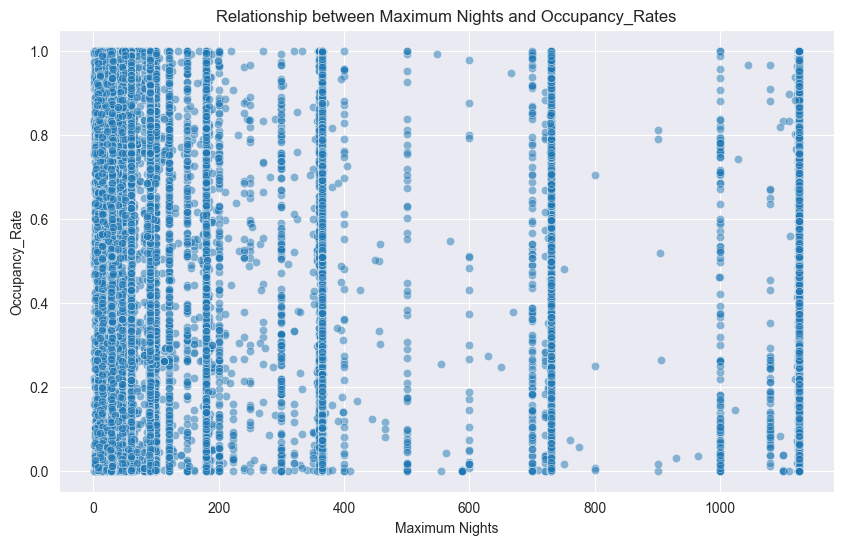

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='maximum_nights', y='Occupancy_Rate', alpha=0.5)
plt.title('Relationship between Maximum Nights and Occupancy_Rates')
plt.xlabel('Maximum Nights')
plt.ylabel('Occupancy_Rate')
plt.grid(True)
plt.show()

In [83]:
mlp_model = MLPRegressor(hidden_layer_sizes=(256, 128, 64),activation='relu', solver='adam', alpha=0.05,
                         batch_size=64, early_stopping=True,validation_fraction=0.2, n_iter_no_change=50,
                         max_iter=2000, random_state=42)
mlp_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.05
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [84]:
y_pred_raw = mlp_model.predict(X_test)
y_pred = np.clip(y_pred_raw, 0.0, 1.0)

print(f"MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.25847129016331194
R2 Score: 0.1612642469602238


Mieszkania o identycznych parametrach (ta sama ulica, 2 pokoje, ta sama cena, to samo wyposażenie) mogą mieć skrajnie różne obłożenie z powodów, których Twój model nie "widzi":

Jakość zdjęć: To absolutnie kluczowy czynnik na Airbnb. Piękne, jasne, profesjonalne zdjęcia sprzedają ofertę. Ciemne zdjęcia z telefonu odstraszają, mimo że obiektywnie mieszkanie ma "te same parametry".

Algorytm pozycjonowania Airbnb: Nowe oferty często dostają "boost" widoczności, a host z odznaką Superhost pojawia się wyżej w wynikach wyszukiwania.

Dynamiczne ceny (Smart Pricing): Twój model widzi uśrednioną cenę bazową. W rzeczywistości skuteczni hostowie obniżają ceny na luty i podnoszą na sylwestra.

Marketing zewnętrzny: Niektórzy hostowie reklamują swoje apartamenty na Instagramie lub Bookingu, sztucznie pompując kalendarz w Airbnb (który może zaczytywać te rezerwacje jako "niedostępne").

# Occupancy prediction

In [85]:
X_columns = X.columns
medians = X.median()

def predict_occupancy(model, scaler, user_params, columns_list, base_values):
    df_sim = pd.DataFrame(np.zeros((1, len(columns_list))), columns=columns_list)

    for col in base_values.index:
        if col in df_sim.columns:
            df_sim.at[0, col] = base_values[col]

    for key, value in user_params.items():
        if key in columns_list:
            df_sim.at[0, key] = value
        else:
            print(f"Column '{key}' does not exist in the model.")

    df_sim_scaled = scaler.transform(df_sim)

    prediction = model.predict(df_sim_scaled)[0]
    return prediction

In [86]:
params = {
    'accommodates': 4,
    'beds': 2,
    'bathrooms': 1.5,
    'price': 150,
    'minimum_nights': 2,
    'neighbourhood_cleansed_Westminster': 1,
    'property_type_Entire rental unit': 1
}

predict = predict_occupancy(model=best_rf, scaler=scaler, user_params=params, columns_list=X_columns,base_values=medians)

print(f"Estimated occupancy: {predict:.2%}")

Estimated occupancy: 47.97%


In [87]:
prices = [10, 80, 100, 120, 150, 180, 200, 250, 300, 1000, 50000]
simulation_results = []

apartment_base = {
    'accommodates': 4,
    'beds': 2,
    'neighbourhood_cleansed_Westminster': 1,
    'maximum_nights': 20,
    'instant_bookable': 0
}

for test_price in prices:
    params = apartment_base.copy()
    params['price'] = test_price

    occ_rate = predict_occupancy(best_rf, scaler, params,
                                 X_columns, medians)
    estimated_revenue = test_price * occ_rate * 365

    simulation_results.append({
        'Price per night': test_price,
        'Estimated occupancy': occ_rate,
        'Estimated revenue': estimated_revenue
    })

table = pd.DataFrame(simulation_results)

table['Estimated occupancy'] = (
    table['Estimated occupancy']
    .apply(lambda x: f"{x:.2%}")
)

table['Estimated revenue'] = (
    table['Estimated revenue']
    .round()
    .astype(int)
)

print(table)

    Price per night Estimated occupancy  Estimated revenue
0                10              73.95%               2699
1                80              75.07%              21919
2               100              75.69%              27627
3               120              75.50%              33071
4               150              72.94%              39934
5               180              67.45%              44314
6               200              66.00%              48179
7               250              62.80%              57303
8               300              60.50%              66250
9              1000              48.56%             177260
10            50000              48.96%            8934418


In [88]:
data.groupby('bedrooms')['avg_price_by_numberroms'].nunique()

bedrooms
0      1
1     80
2     86
3     87
4     80
5     61
6     44
7     20
8     11
9      7
10     4
14     1
20     1
Name: avg_price_by_numberroms, dtype: int64

In [89]:
params_studio = {
    'accommodates': 2,
    'beds': 1,
    'bathrooms': 1,
    'price': 80,
    #'minimum_nights': 1,
    #'maximum_nights': 14,
    #'instant_bookable': 1,
    #'host_response_rate': 100,
    #'host_acceptance_rate': 100,
    'property_type_Entire rental unit': 1,
    'neighbourhood_cleansed_Hackney': 1
}

In [90]:
params_standard = {
    'accommodates': 4,
    'beds': 2,
    'bathrooms': 1.5,
    'price': 150,
    #'minimum_nights': 2,
    #'maximum_nights': 14,
    #'instant_bookable': 1,
    #'host_response_rate': 100,
    #'host_acceptance_rate': 100,
    'property_type_Entire rental unit': 1,
    'neighbourhood_cleansed_Westminster': 1
}

In [91]:
params_luxury = {
    'accommodates': 8,
    'beds': 4,
    'bathrooms': 3,
    'price': 350,
    #'minimum_nights': 3,
    #'maximum_nights': 14,
    #'instant_bookable': 0,
    #'host_response_rate': 95,
    #'host_acceptance_rate': 95,
    'property_type_Entire rental unit': 1,
    'neighbourhood_cleansed_Kensington and Chelsea': 1
}

In [92]:
for name, params in {
    "Studio": params_studio,
    "Standard": params_standard,
    "Luxury": params_luxury
}.items():

    occupancy = predict_occupancy(
        model=best_rf,
        scaler=scaler,
        user_params=params,
        columns_list=X_columns,
        base_values=medians
    )

    print(f"{name}: {occupancy:.2%}")

Studio: 49.70%
Standard: 47.97%
Luxury: 41.70%


In [93]:
apartment_base = {
    'accommodates': 4,
    'beds': 2,
    'bathrooms': 1.5,
    'minimum_nights': 2,
    'maximum_nights': 30,
    'instant_bookable': 1,
    'host_response_rate': 100,
    'host_acceptance_rate': 100,
    'property_type_Entire rental unit': 1,
    'neighbourhood_cleansed_Westminster': 1
}

In [94]:
prices = np.arange(50, 401, 5)

results = []

for price in prices:

    params = apartment_base.copy()
    params['price'] = price

    occupancy = predict_occupancy(
        best_rf,
        scaler,
        params,
        X_columns,
        medians
    )

    revenue = price * occupancy * 365

    results.append({
        'Price': price,
        'Occupancy': occupancy,
        'Revenue': revenue
    })

results_df = pd.DataFrame(results)

optimum = results_df.loc[results_df['Revenue'].idxmax()]

print("Optimal price:")
print(f"Price: £{optimum['Price']:.0f}")
print(f"Occupancy: {optimum['Occupancy']:.2%}")
print(f"Revenue: £{optimum['Revenue']:.0f}")

Optimal price:
Price: £395
Occupancy: 53.51%
Revenue: £77152


In [95]:
avg_price = data.loc[
    (data['neighbourhood_cleansed_Westminster'] == 1) &
    (data['bedrooms'] == 2),
    'avg_price_by_numberroms'
].mean()

print(f"Average property value: {avg_price:,.2f}")

Average property value: 627,368.85


In [96]:
yield_value = optimum['Revenue'] / avg_price

print(f"Yield: {yield_value:.2%}")

Yield: 12.30%
